## 1 — Hook: what this notebook actually covers

Lionel Messi signed for Inter Miami in July 2023. StatsBomb released event-level data from **six** of his matches as part of an Open Data drop — and that six-match sample is the **entire publicly available MLS 2023 event corpus**. Every other team in the league has zero matches in this dataset.

So when this notebook says "MLS 2023," it means these six Miami matches — **August through October 2023**, the 2nd half-season after Messi arrived. Philadelphia Union, Columbus Crew, and every other MLS team cannot be measured at event level here. (See `docs/data_reality.md` §1 for the full coverage audit.)

The story below is about this six-match corpus, nothing more and nothing less. All interpretations are **associational** — describing patterns in the data, not proving causes.

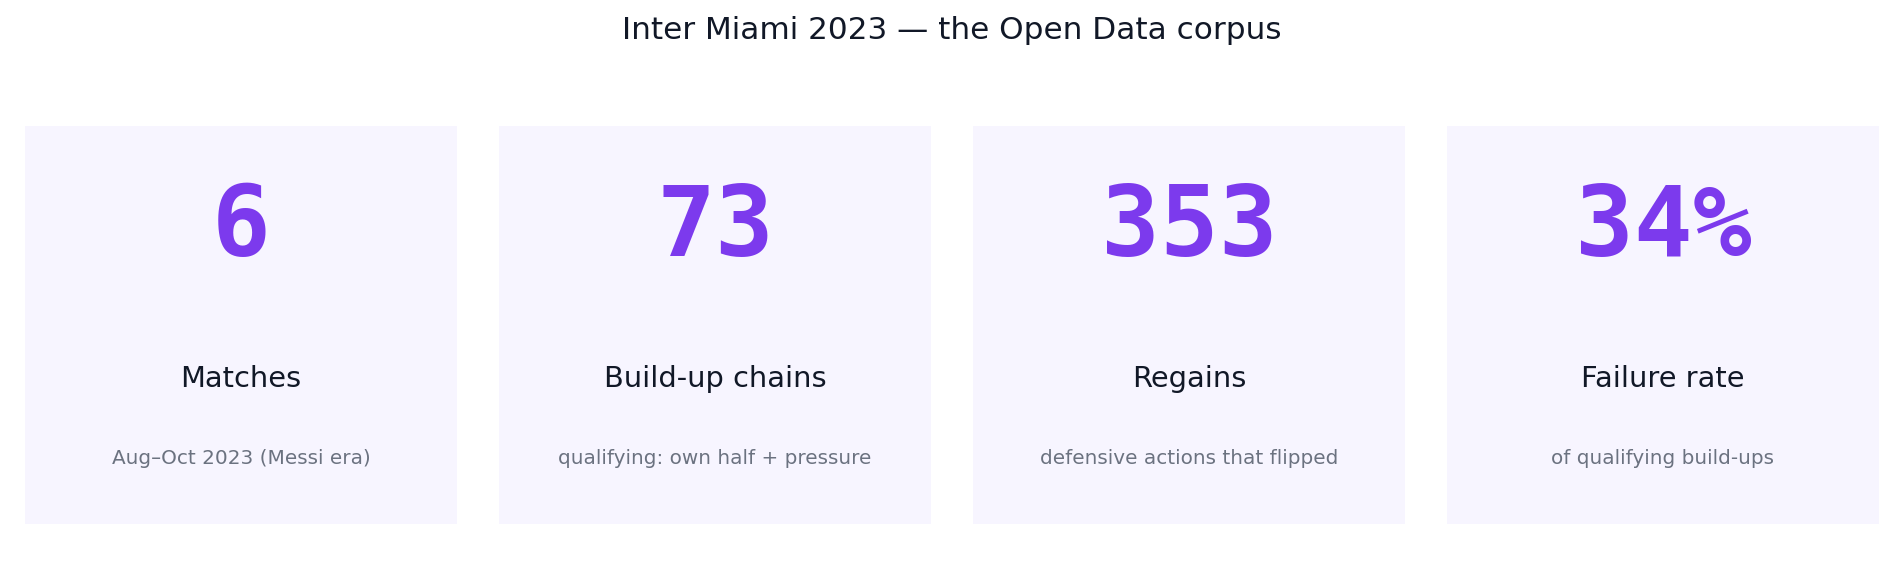

In [1]:
from IPython.display import Image

from pressured_progression.analysis.build_case_study_figures import (
    FIG_DIR,
    buildup_failure_rate,
    case_summary,
    hook_snapshot,
    post_regain_metrics,
    pressure_exposure,
    regain_outcome_sankey,
    top_shap_features,
)

hook_snapshot(save=True)
Image(str(FIG_DIR / "case_study_01_hook.png"))

## 2 — Pressure exposure profile

When Inter Miami were pressed in their own half, where did those encounters end up? The hexbin shows where they won the ball back across these six matches. A regain in the defensive third (the left shaded band) means pressure was faced and eventually resolved there. A regain higher up means the ball was contested further from goal.

The darker mass sits between the defensive and middle thirds — consistent with a team that absorbs pressure before trying to counter-attack, not one that presses the opponent high. That doesn't make the profile good or bad; it's a description of where the fight for the ball actually happened.

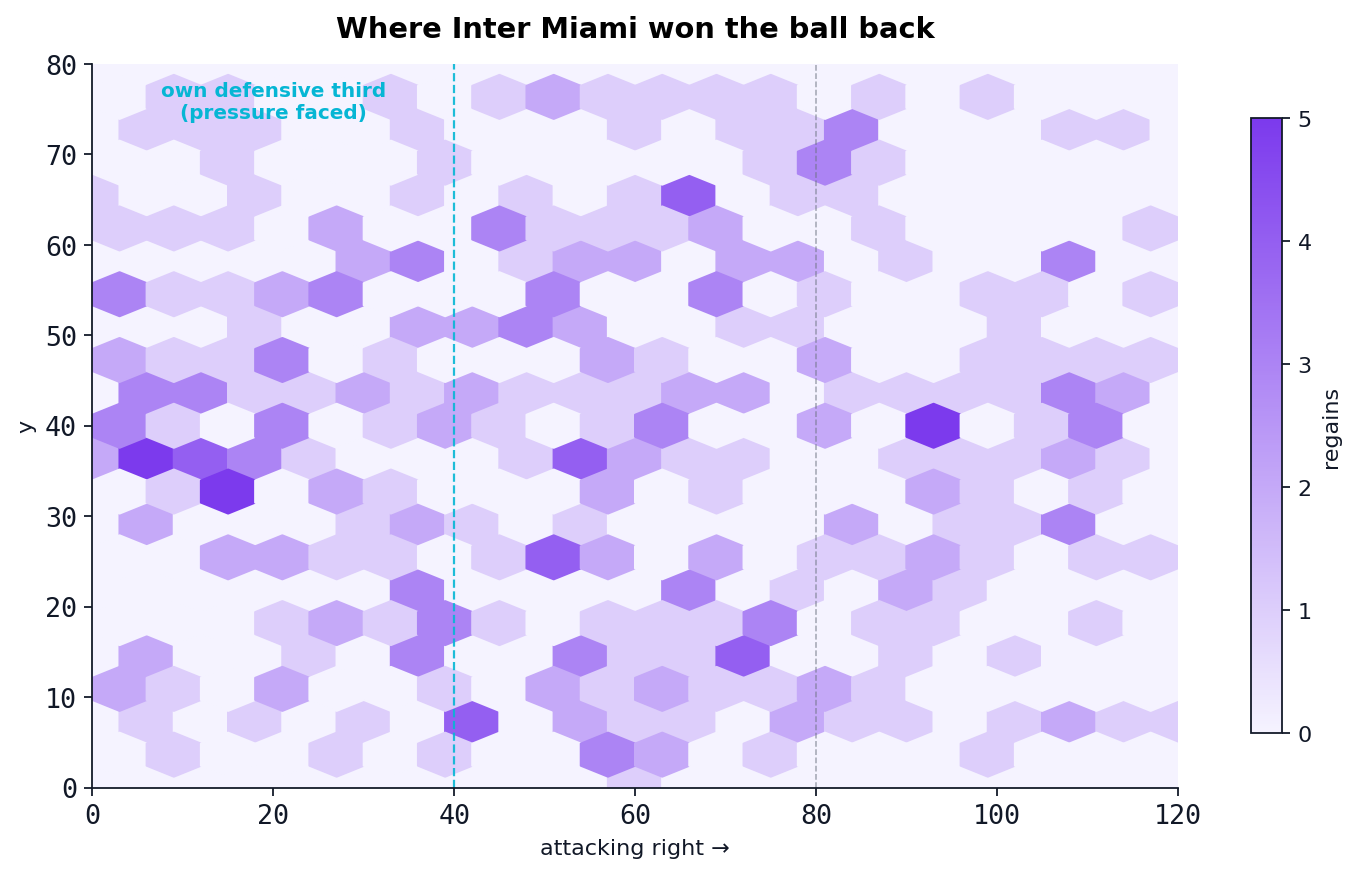

In [2]:
pressure_exposure(save=True)
Image(str(FIG_DIR / "case_study_02_pressure_exposure.png"))

## 3 — Build-up failure rate (Module A)

The **build-up failure label** captures a specific thing: a possession that (a) starts in the defensive third, (b) faces opponent pressure within its first three actions, and (c) ends in one of four failure modes — dispossession in own half, a forced long ball that gets lost, an opponent shot within 10 seconds of the turnover, or a backward reset followed by loss inside five actions.

Across 73 qualifying build-ups, **34% ended in failure**. The 95% confidence interval is **[25%, 45%]** — wide, because six matches is a small sample. Read the direction, not the decimal: under pressure in its own half, this team lost the ball about one in three qualifying possessions. Whether that's high or low relative to the MLS average cannot be answered here — no other MLS team has event data in Open Data to compare.

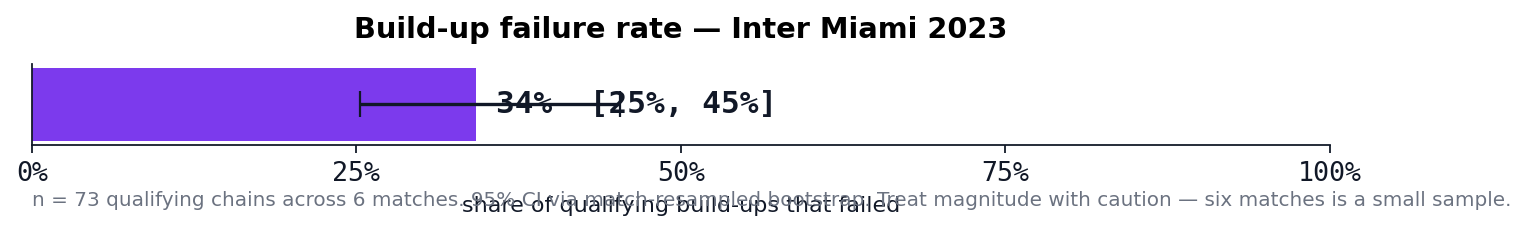

In [3]:
buildup_failure_rate(save=True)
Image(str(FIG_DIR / "case_study_03_buildup_failure_rate.png"))

## 4 — What drove predicted failure (top SHAP features)

When the XGBoost classifier flagged a build-up as likely to fail, these five features carried the most weight. Each maps to a football concept:

- **First receiver's passing-network centrality** — how connected the player receiving the first pass is to the rest of the team. A less-central receiver is harder to support on the next action.
- **Defensive-third pressure density** — how much opponent pressure the play navigated in its first 30 seconds.
- **Opponent press height** — where the opposing team had been winning ball recoveries in the prior 30 seconds; a rough proxy for how high they were defending.
- **Game state (tied, 0–0)** — possessions while the score is level often play differently from chasing or protecting leads.
- **Time-to-pressure on the first receiver** — how quickly an opponent closed down the player who received the pass.

None of these "cause" failure. They're the variables the model found useful to split on, given this specific 73-chain training set. With a larger sample the ranking could shift.

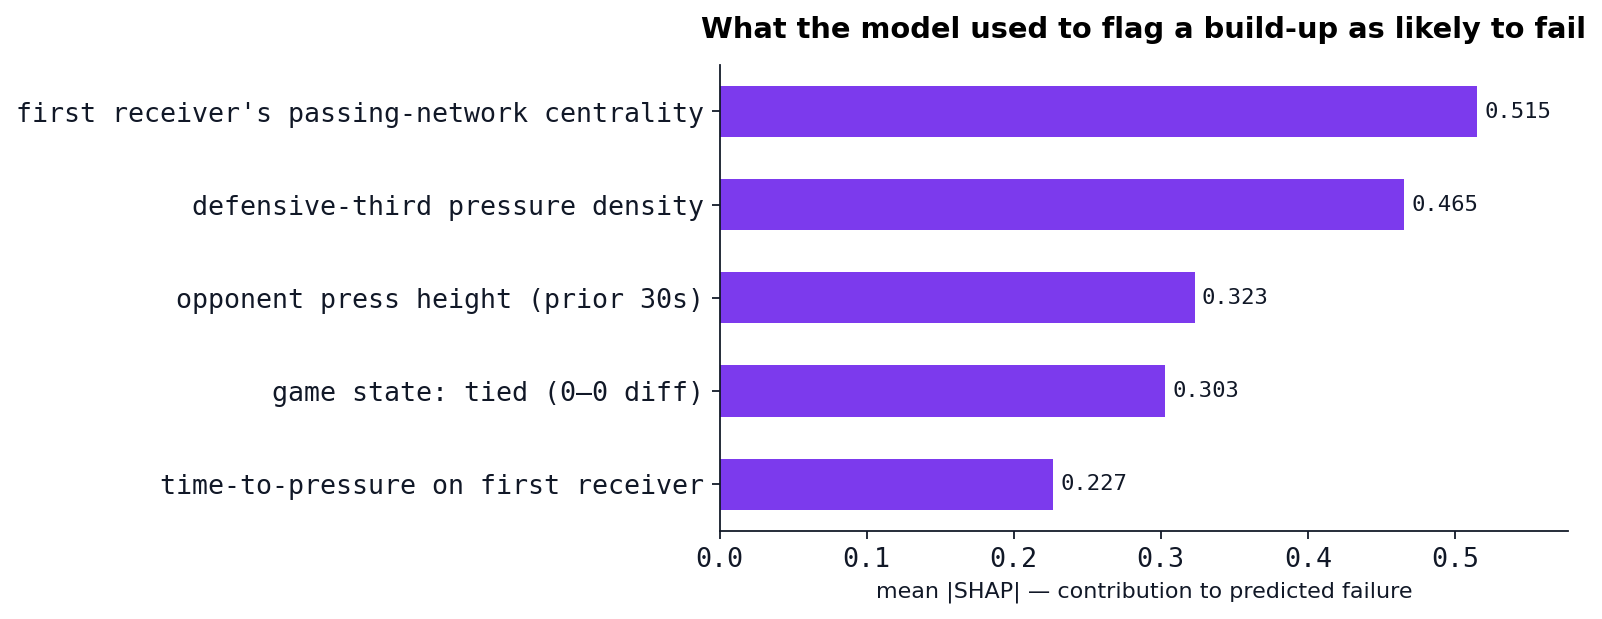

In [4]:
top_shap_features(save=True)
Image(str(FIG_DIR / "case_study_04_top_shap.png"))

## 5 — Post-regain decision quality (Module B)

Winning the ball is only half the job — what happens next decides whether a regain matters. Six metrics describe that, each with a 95% CI.

**Lead with the waste signal:** of the 353 regains, **90% did not lead to a shot within 15 seconds**. Winning the ball is, in this corpus, not the problem. Converting a regain into a threat is. Where shots did happen, the median time-to-shot was 5.5 seconds — quick counter-attacks — and roughly a third of those were low-xG (<0.05) rushed attempts. Two-thirds of regains reached the final third, but most didn't produce a shot from there.

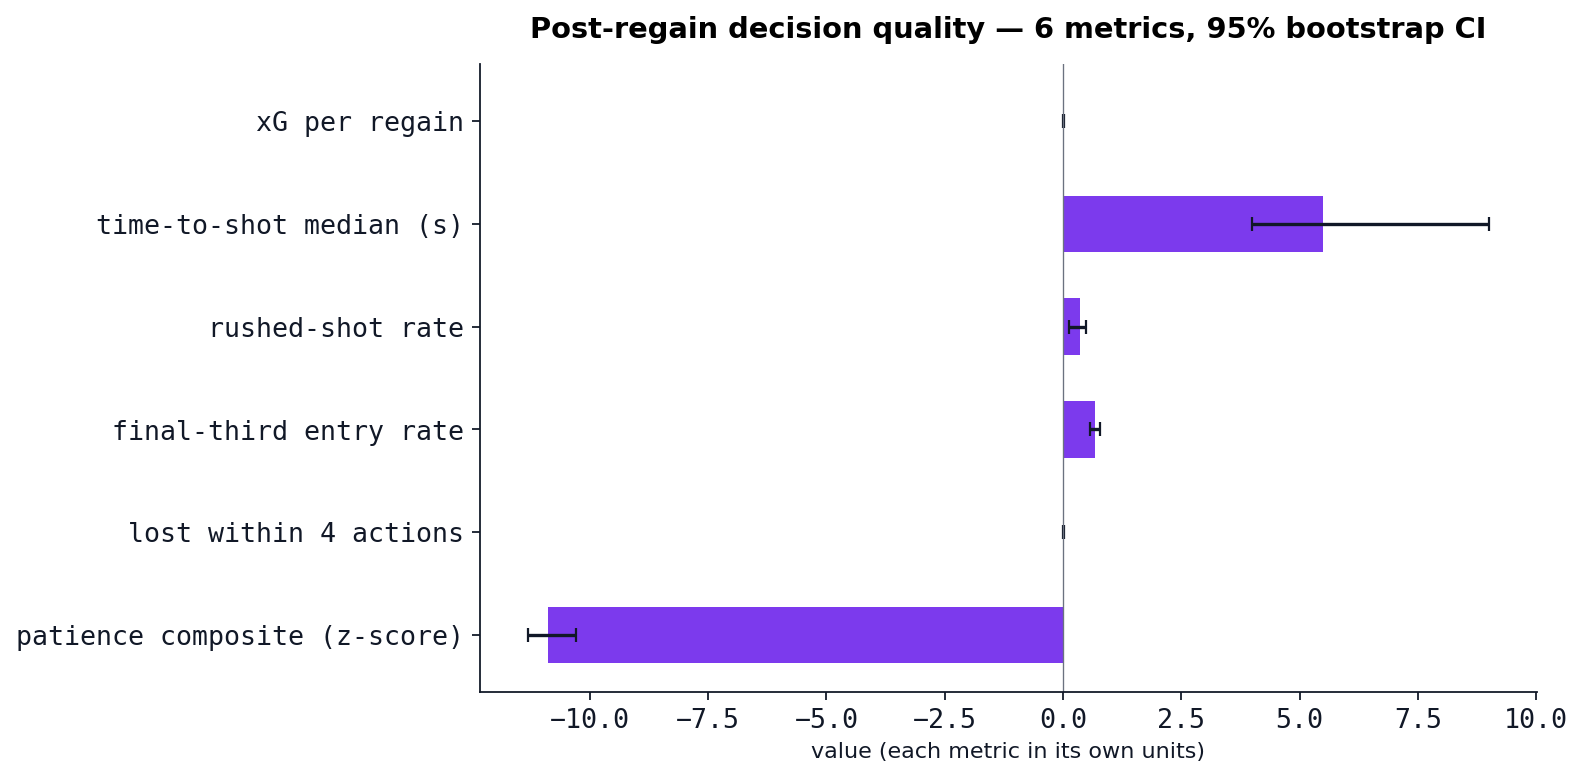

In [5]:
post_regain_metrics(save=True)
Image(str(FIG_DIR / "case_study_05_post_regain_metrics.png"))

## 6 — Regain outcomes, in flow

The Sankey makes the pattern concrete. The **modal outcome is "other"** — long dwells, fouls won, half ends, slow retention that doesn't cleanly resolve in 15 seconds. The **second most common outcome is reaching the final third without creating a shot**. Possession loss within four actions is rare (~1%). Only a small band flows into "shot within 15s."

This shape coincides with — but is not identical to — the Philadelphia Union 2026 narrative profiled in the *Inquirer*: rushed build-ups that bypass the midfield and die in the opponent's half. The mechanism differs (rushed long balls vs. slow territorial retention), but the underlying thesis is the same: **regains that don't translate into threat**. Two teams, two seasons apart, both stuck on the conversion step of the same equation.

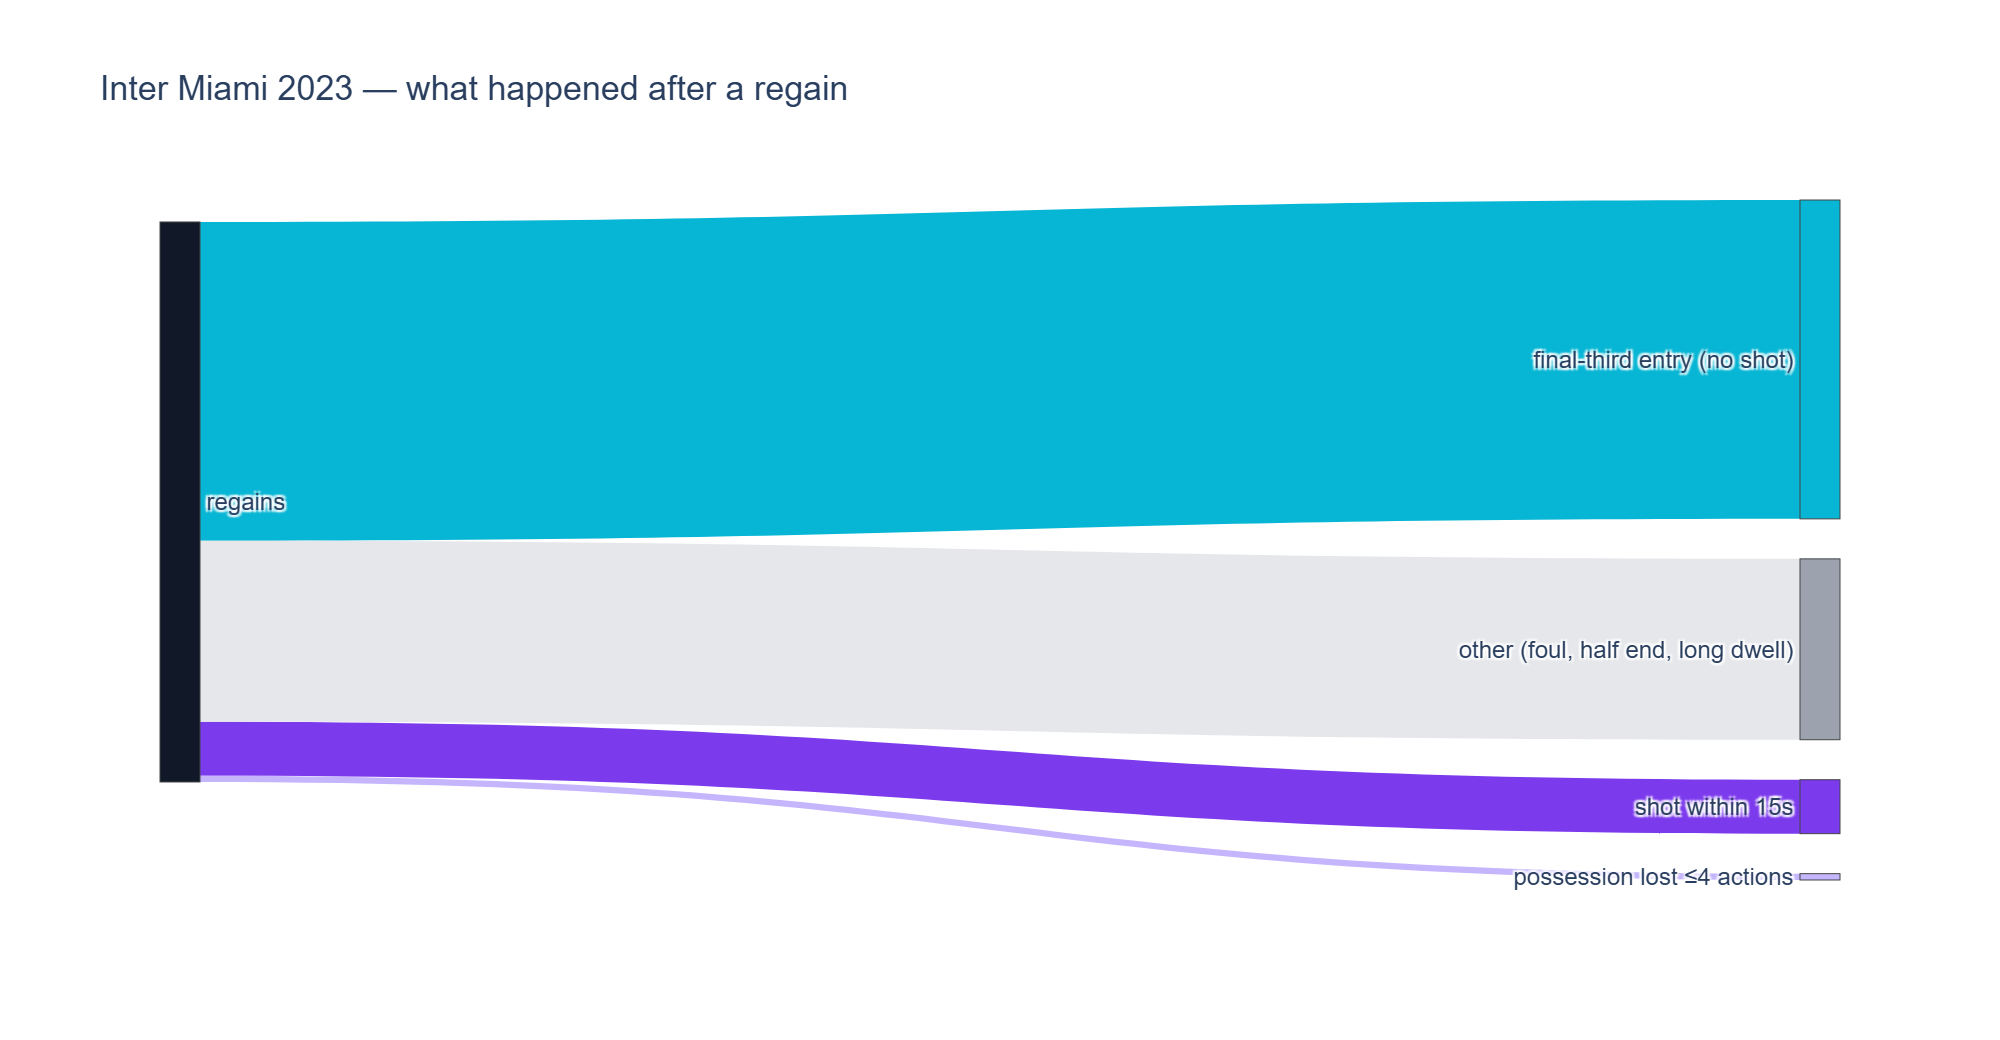

In [6]:
regain_outcome_sankey(save=True)
Image(str(FIG_DIR / "case_study_06_sankey.png"))

## 7 — What this profile looks like, in one paragraph

Inter Miami 2023, across its six-match Open Data corpus, looks like a team that **often reaches the final third after winning the ball, yet rarely turns that territory into a shot** — and that **fails roughly one in three qualifying build-ups** when pressed deep in its own half. The regain mass sits in the middle and defensive thirds rather than high up the pitch, the shots that do follow regains tend to come quickly (median 5.5 seconds), and nine in ten regains never become a shot inside fifteen seconds.

That's the profile. **What it does not say**: it does not say the team should play differently, that the coach is right or wrong, or that Messi is being misused. Roster age, schedule density, opponent quality, the small sample, and pure chance all contribute to the numbers, and none of them can be isolated from six matches. The value of this corpus is descriptive — a baseline for the article's comparison to the transformed Leverkusen side in Module C, and a reference point for articulating the thesis in plain language.

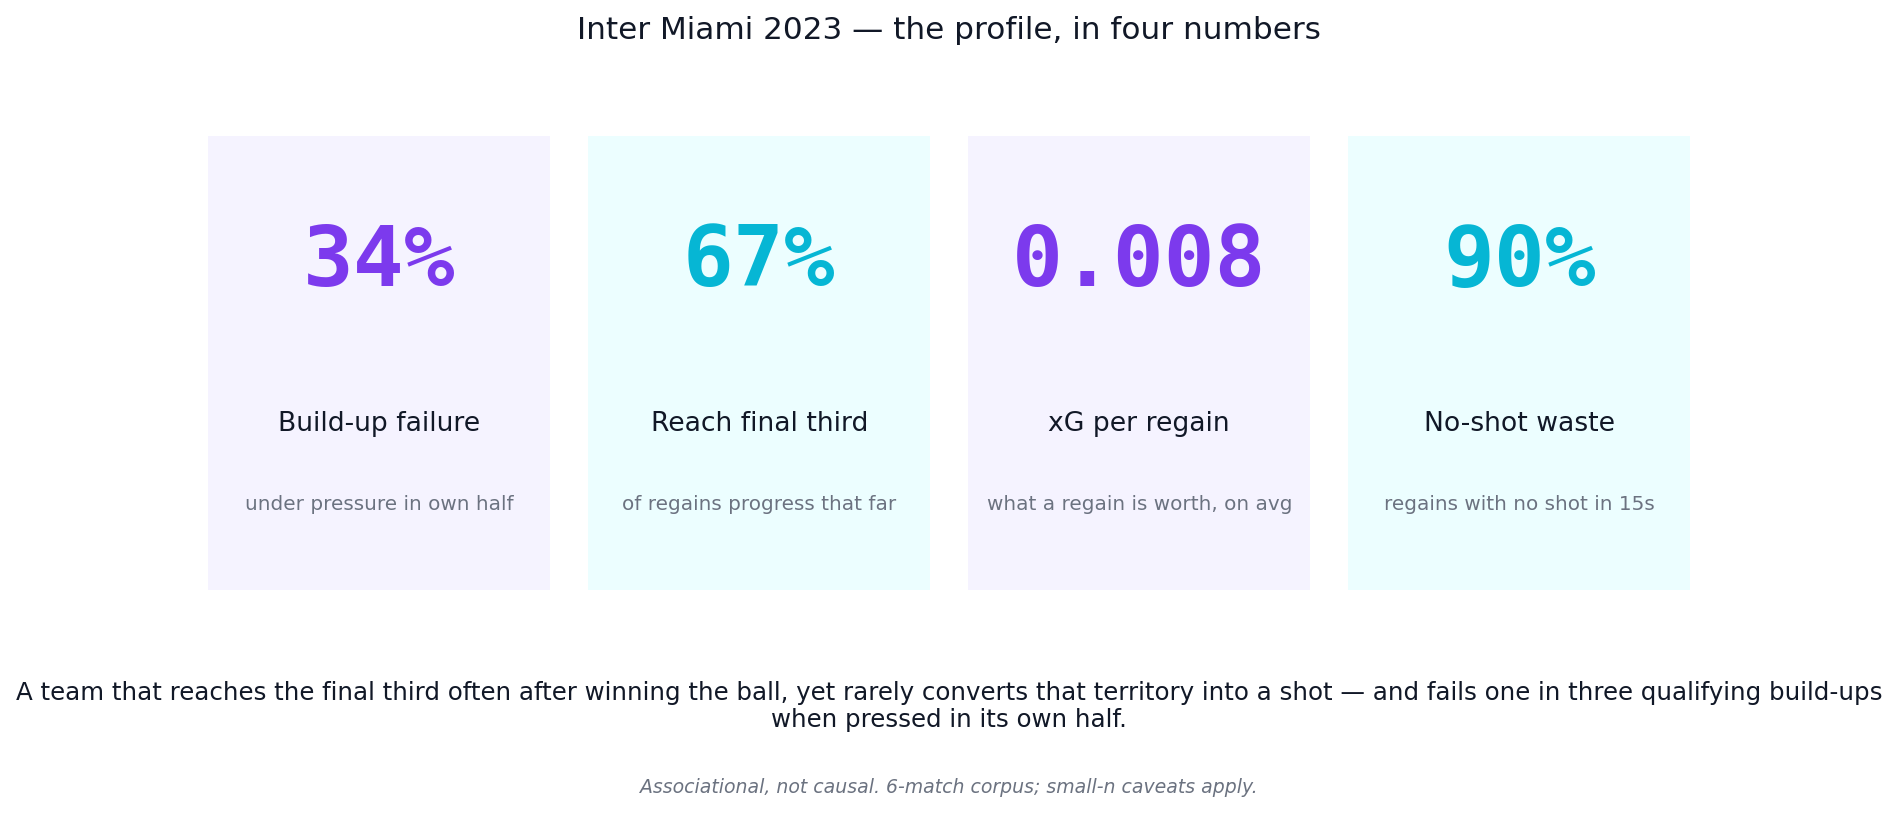

In [7]:
case_summary(save=True)
Image(str(FIG_DIR / "case_study_07_summary.png"))